In [19]:
import matplotlib.pyplot as plt
import pandas as pd

PINK = ["#B85072", "#D87093", "#FF9AA2", "#FFB6C1", "#FFE4E1", "#FFF0F5"]

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
LABEL = "Adenia | 2455301211"


def simpan(nama):
  plt.tight_layout()
  plt.savefig(nama, dpi=120)
  plt.show()

In [20]:
#Tabel Data
path = r"adenia.xlsx"
dataraw = pd.read_excel(path)
print(f"Data berhasil dibaca: {dataraw.shape[0]} baris x {dataraw.shape[1]} kolom\n")
print(dataraw)

Data berhasil dibaca: 30 baris x 7 kolom

           NIM                        Name  KUIS  UTS  UAS  Nilai Grade
0   2455301211  Adenia Faridhotul Musthofa    95   88   90  90.94     A
1       120005                  Jane Smith    92   88   94  91.38     A
2       120017             Michael Johnson    48   65   56  56.41     C
3       120018                 Emily Brown    90   85   88  87.65     A
4       120022             Daniel Martinez    75   80   77  77.35    AB
5       120024                Sarah Wilson    88   70   65  74.01     B
6       120025                David Garcia    75   70   75  73.35     B
7       120027                 Jessica Lee    95   91   96  94.03     A
8       120034               Matthew Davis    79   84   78  80.30    AB
9       120035          Jennifer Rodriguez    42   48   63  51.33     C
10      120036               Andrew Taylor    53   64   59  58.73     C
11      120038            Amanda Hernandez    91   95   90  91.97     A
12      120039        

In [21]:
#Tabel Frekuensi
datafrq = pd.crosstab(index=dataraw["Grade"], columns="Frekuensi")
tabel = datafrq.copy()
tabel["Proporsi (%)"] = (tabel["Frekuensi"] / tabel["Frekuensi"].sum() * 100).round(2)
tabel.loc["TOTAL"] = [tabel["Frekuensi"].sum(), 100.0]
tabel["Frekuensi"] = tabel["Frekuensi"].astype(int)
print(tabel)

col_0  Frekuensi  Proporsi (%)
Grade                         
A             12         40.00
AB             7         23.33
B              4         13.33
BC             1          3.33
C              5         16.67
F              1          3.33
TOTAL         30        100.00


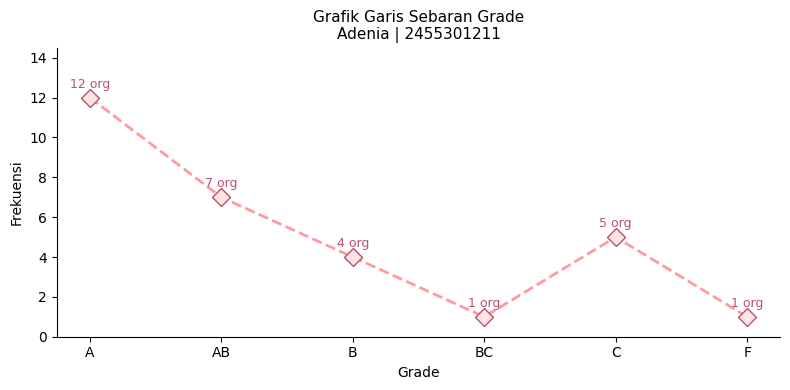

In [24]:
# Grafik Garis
plt.figure(figsize=(8, 4))
plt.plot(
    datafrq.index,
    datafrq["Frekuensi"],
    linestyle="--",
    marker="D",
    markersize=9,
    color=PINK[2],
    markerfacecolor=PINK[4],
    markeredgecolor=PINK[0],
    linewidth=2,
)

for x, y in zip(datafrq.index, datafrq["Frekuensi"]):
  plt.text(x, y + 0.5, f"{y} org", ha="center", fontsize=9, color=PINK[0])

plt.ylim(0, datafrq["Frekuensi"].max() + 2.5)
plt.title("Grafik Garis Sebaran Grade\n" + LABEL, fontsize=11)
plt.xlabel("Grade")
plt.ylabel("Frekuensi")
simpan("adenia_garis.png")

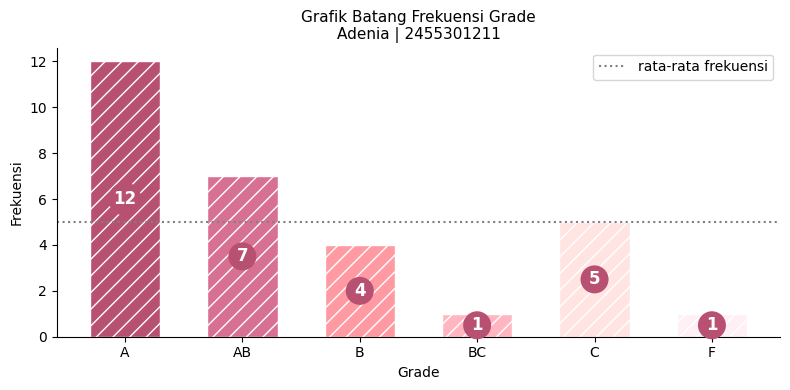

In [25]:
# Grafik Batang
plt.figure(figsize=(8, 4))
bar = plt.bar(
    datafrq.index,
    datafrq["Frekuensi"],
    color=PINK,
    width=0.6,
    hatch="//",
    edgecolor="white",
)
for b in bar:
  plt.text(
      b.get_x() + b.get_width() / 2,
      b.get_height() / 2,
      int(b.get_height()),
      ha="center",
      va="center",
      color="white",
      fontsize=12,
      fontweight="bold",
      bbox=dict(boxstyle="circle", fc=PINK[0], ec="none"),
  )
plt.axhline(
    datafrq["Frekuensi"].mean(),
    color="gray",
    linestyle=":",
    label="rata-rata frekuensi",
)
plt.legend()
plt.title("Grafik Batang Frekuensi Grade\n" + LABEL, fontsize=11)
plt.xlabel("Grade")
plt.ylabel("Frekuensi")
simpan("adenia_batang.png")

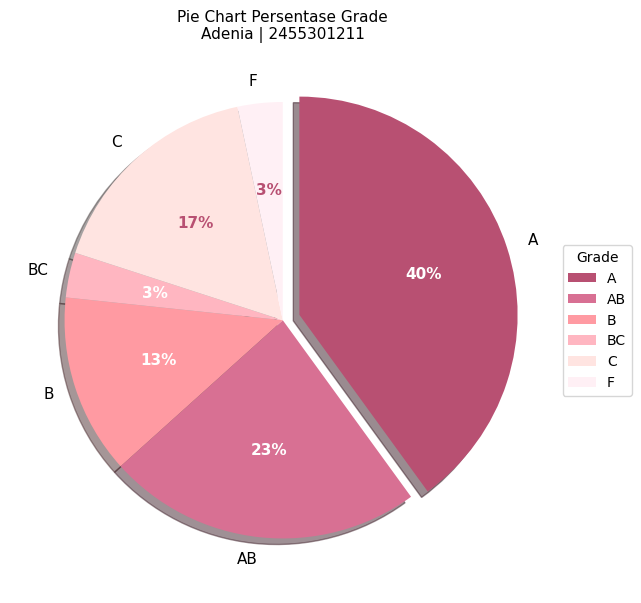

In [26]:
# Pie Chart
ax = datafrq.plot(
    kind="pie",
    y="Frekuensi",
    autopct="%1.0f%%",
    legend=False,
    colors=PINK,
    shadow=True,
    startangle=90,
    counterclock=False,
    figsize=(6.5, 6.5),
    explode=[0.08 if g == "A" else 0 for g in datafrq.index],
    textprops={"fontsize": 11},
)
persen = [t for t in ax.texts if "%" in t.get_text()]
for i, t in enumerate(persen):
  t.set_color("white" if i < 4 else PINK[0])
  t.set_fontweight("bold")
ax.legend(
    datafrq.index, title="Grade", loc="center left", bbox_to_anchor=(1, 0.5)
)
ax.set_ylabel("")
ax.set_title("Pie Chart Persentase Grade\n" + LABEL, fontsize=11)
simpan("adenia_pie.png")

In [13]:
#Statistika Deskriptif
dataraw["Nilai"] = pd.to_numeric(dataraw["Nilai"], errors='coerce')
dt = dataraw["Nilai"]
stats = dt.describe()
stats['Standard Error'] = dt.sem()
stats['Median'] = dt.median()
stats['Mode'] = dt.mode().iloc[0]
stats['variance'] = dt.var()
stats['range'] = dt.max() - dt.min()
stats['skewness'] = dt.skew()
stats['kurtosis'] = dt.kurtosis()
print("╔══════════ STATISTIKA DESKRIPTIF ══════════╗")
for k, v in stats.items():
    print(f"  {k:<18}: {v:>12.4f}")
print("╚═══════════════════════════════════════════╝")

╔══════════ STATISTIKA DESKRIPTIF ══════════╗
  count             :      30.0000
  mean              :      76.4380
  std               :      13.6544
  min               :      46.0100
  25%               :      68.0950
  50%               :      78.8000
  75%               :      87.5600
  max               :      94.0300
  Standard Error    :       2.4929
  Median            :      78.8000
  Mode              :      77.3000
  variance          :     186.4415
  range             :      48.0200
  skewness          :      -0.6500
  kurtosis          :      -0.5817
╚═══════════════════════════════════════════╝


IQR = 19.465 | batas outlier: 38.90 s/d 116.76
Outlier: tidak ada
Modus lengkap: [77.3, 80.3]


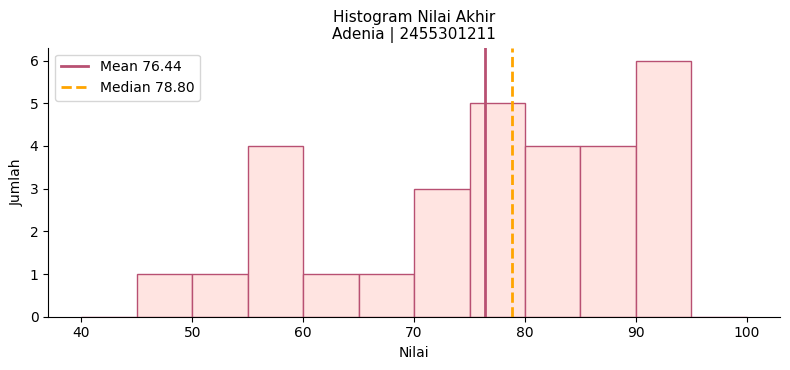

In [29]:
# Histogram + garis mean/median & cek outlier
q1, q3 = dt.quantile([0.25, 0.75])
iqr = q3 - q1
print(f"IQR = {iqr:.3f} | batas outlier: {q1-1.5*iqr:.2f} s/d {q3+1.5*iqr:.2f}")
print(
    "Outlier:",
    dt[(dt < q1 - 1.5 * iqr) | (dt > q3 + 1.5 * iqr)].tolist() or "tidak ada",
)
print("Modus lengkap:", dt.mode().tolist())

plt.figure(figsize=(8, 3.8))
plt.hist(dt, bins=range(40, 101, 5), color=PINK[4], edgecolor=PINK[0])
plt.axvline(
    dt.mean(), color=PINK[0], linewidth=2, label=f"Mean {dt.mean():.2f}"
)
plt.axvline(
    dt.median(),
    color="orange",
    linestyle="--",
    linewidth=2,
    label=f"Median {dt.median():.2f}",
)
plt.legend()
plt.title("Histogram Nilai Akhir\n" + LABEL, fontsize=11)
plt.xlabel("Nilai")
plt.ylabel("Jumlah")
simpan("adenia_histogram.png")